In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!pip install spacy transformers torch torchvision torchaudio accelerate datasets scikit-learn rouge-score
!python -m spacy download en_core_web_sm


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import os
import gc
import math
import json
import random
from pathlib import Path

import spacy
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForSeq2SeqLM, pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from rouge_score import rouge_scorer

BASE_DIR = Path("/content/drive/MyDrive/data")
TXT_10K_DIR = BASE_DIR / "text" / "10k"
TXT_SUS_DIR = BASE_DIR / "text" / "sus"
INTERMEDIATE_DIR = BASE_DIR / "intermediate"
RESULTS_DIR = BASE_DIR / "results"

INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ESG_MODEL_NAME = "distilbert-base-uncased"
FINBERT_MODEL_NAME = "yiyanghkust/finbert-tone"
SUMMARIZER_MODEL_NAME = "facebook/bart-large-cnn"
GREENWASH_MODEL_NAME = "distilbert-base-uncased"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)


In [7]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "tagger", "lemmatizer", "parser"])
sentencizer = nlp.add_pipe("sentencizer")


In [8]:
def txt_to_text(path):
    return path.read_text(encoding="utf-8", errors="ignore")

def text_to_sentences(text, max_chars=5000, max_sentences_per_doc=2000):
    sentences = []
    for i in range(0, len(text), max_chars):
        chunk = text[i:i+max_chars]
        doc = nlp(chunk)
        for sent in doc.sents:
            s = sent.text.strip()
            if len(s) > 5:
                sentences.append(s)
            if len(sentences) >= max_sentences_per_doc:
                return sentences
    return sentences


In [9]:
ESG_KEYWORDS = {
    "E": ["emission", "climate", "carbon", "co2", "environment", "pollution", "energy", "waste", "renewable", "water", "biodiversity"],
    "S": ["diversity", "inclusion", "community", "safety", "labor", "employee", "well-being", "wage", "human rights", "health", "training"],
    "G": ["board", "governance", "audit", "compliance", "ethics", "bribery", "corruption", "shareholder", "committee", "transparency"]
}

def baseline_esg_pillar(sentence):
    s_lower = sentence.lower()
    scores = {"E": 0, "S": 0, "G": 0}
    for pillar, words in ESG_KEYWORDS.items():
        for w in words:
            if w in s_lower:
                scores[pillar] += 1
    max_score = max(scores.values())
    if max_score == 0:
        return "None"
    candidates = [p for p, v in scores.items() if v == max_score]
    if len(candidates) == 1:
        return candidates[0]
    return ",".join(sorted(candidates))


In [10]:
def process_txt_dir(in_dir, source_type):
    in_dir = Path(in_dir)
    csv_paths = []
    for path in tqdm(list(in_dir.glob("*.txt"))):
        text = txt_to_text(path)
        sentences = text_to_sentences(text)
        rows = []
        for s in sentences:
            pillar_baseline = baseline_esg_pillar(s)
            rows.append(
                {
                    "doc_id": path.stem,
                    "source_type": source_type,
                    "sentence": s,
                    "pillar_baseline": pillar_baseline,
                }
            )
        df = pd.DataFrame(rows)
        out_path = INTERMEDIATE_DIR / f"{path.stem}_{source_type}_sentences.csv"
        df.to_csv(out_path, index=False)
        csv_paths.append(out_path)
        del df, rows, sentences, text
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return csv_paths

k10_csvs = process_txt_dir(TXT_10K_DIR, "10k")
sus_csvs = process_txt_dir(TXT_SUS_DIR, "sustainability")


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [11]:
all_sentence_csvs = list(INTERMEDIATE_DIR.glob("*_sentences.csv"))
dfs = [pd.read_csv(p) for p in all_sentence_csvs]
sentences_df = pd.concat(dfs, ignore_index=True)
sentences_df.to_csv(INTERMEDIATE_DIR / "all_sentences_baseline.csv", index=False)
del dfs
gc.collect()


80

In [12]:
esg_tokenizer = AutoTokenizer.from_pretrained(ESG_MODEL_NAME)
esg_model = AutoModelForSequenceClassification.from_pretrained(ESG_MODEL_NAME).to(DEVICE)
esg_model.eval()
ESG_LABELS = ["E", "S", "G", "None"]

def esg_predict_batch(sent_list, batch_size=16, max_length=128):
    all_labels = []
    for i in range(0, len(sent_list), batch_size):
        batch = sent_list[i:i+batch_size]
        enc = esg_tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = esg_model(**enc).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy().tolist()
        for p in preds:
            if p < len(ESG_LABELS):
                all_labels.append(ESG_LABELS[p])
            else:
                all_labels.append("None")
        del enc, logits
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return all_labels


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
import pandas as pd
import gc

sentences_df = pd.read_csv(INTERMEDIATE_DIR / "all_sentences_baseline.csv")

sentences_df["pillar_model"] = sentences_df["pillar_baseline"]

sentences_df.to_csv(INTERMEDIATE_DIR / "all_sentences_esg_model.csv", index=False)

del sentences_df
gc.collect()


447

In [24]:
finbert = pipeline(
    "text-classification",
    model=FINBERT_MODEL_NAME,
    tokenizer=FINBERT_MODEL_NAME,
    device=0 if DEVICE == "cuda" else -1,
    truncation=True
)

def sentiment_predict_batch(sent_list, batch_size=16, max_length=128):
    labels = []
    scores = []
    for i in range(0, len(sent_list), batch_size):
        batch = sent_list[i:i+batch_size]
        outputs = finbert(batch, truncation=True, max_length=max_length)
        for out in outputs:
            labels.append(out["label"])
            scores.append(out["score"])
        gc.collect()
    return labels, scores



Device set to use cpu


In [26]:
sentences_df = pd.read_csv(INTERMEDIATE_DIR / "all_sentences_esg_model.csv")

MAX_FINBERT_SENT = 1000

sentences_df["sentiment_label"] = "neutral"
sentences_df["sentiment_confidence"] = 0.0

sample_df = sentences_df.sample(
    n=min(MAX_FINBERT_SENT, len(sentences_df)),
    random_state=42
)

sent_list = sample_df["sentence"].tolist()
sent_labels, sent_scores = sentiment_predict_batch(sent_list, batch_size=16, max_length=64)

sentences_df.loc[sample_df.index, "sentiment_label"] = sent_labels
sentences_df.loc[sample_df.index, "sentiment_confidence"] = sent_scores

sentences_df.to_csv(INTERMEDIATE_DIR / "all_sentences_esg_model_sentiment.csv", index=False)

del sent_list, sent_labels, sent_scores, sample_df
gc.collect()


0

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def extractive_summary(sent_list, max_sentences=5):
    if len(sent_list) == 0:
        return ""
    if len(sent_list) <= max_sentences:
        return " ".join(sent_list)
    vec = TfidfVectorizer(max_features=5000)
    X = vec.fit_transform(sent_list)
    scores = np.asarray(X.sum(axis=1)).ravel()
    top_idx = np.argsort(scores)[-max_sentences:]
    top_idx = sorted(top_idx)
    selected = [sent_list[i] for i in top_idx]
    return " ".join(selected)


In [32]:
sentences_df = pd.read_csv(INTERMEDIATE_DIR / "all_sentences_esg_model_sentiment.csv")

MAX_SUMMARY_SENT = 300

summary_rows = []

for source_type, sub in tqdm(sentences_df.groupby("source_type"), desc="Source type"):
    for pillar in ["E", "S", "G"]:
        pillar_mask = sub["pillar_model"] == pillar
        if pillar_mask.sum() == 0:
            continue
        pillar_sents = sub.loc[pillar_mask, "sentence"]
        if len(pillar_sents) > MAX_SUMMARY_SENT:
            pillar_sents = pillar_sents.sample(n=MAX_SUMMARY_SENT, random_state=42)
        pillar_sents = pillar_sents.tolist()
        summary_text = extractive_summary(pillar_sents, max_sentences=5)
        summary_rows.append(
            {
                "source_type": source_type,
                "pillar": pillar,
                "summary": summary_text,
            }
        )
        gc.collect()

summaries_df = pd.DataFrame(summary_rows)
summaries_df.to_csv(RESULTS_DIR / "corpus_pillar_summaries.csv", index=False)


Source type:   0%|          | 0/2 [00:00<?, ?it/s]

In [37]:
import pandas as pd
import numpy as np
import re

sentences_df = pd.read_csv(INTERMEDIATE_DIR / "all_sentences_esg_model_sentiment.csv")

mask_esg = sentences_df["pillar_model"].isin(["E", "S", "G"])
esg_sents = sentences_df.loc[mask_esg, "sentence"].dropna().drop_duplicates().tolist()

keywords_measurable = [
    "percent", "%", "ton", "tons", "tonnes", "tco2", "co2e",
    "kwh", "gwh", "mwh", "mw", "kw",
    "million", "billion", "thousand",
    "reduced", "reduction", "decreased", "cut", "lowered",
    "increased", "improved", "rise", "drop",
    "target", "goal", "objective", "by", "from"
]

def is_measurable(s):
    s_lower = s.lower()
    if re.search(r"\d", s_lower):
        return 1
    for w in keywords_measurable:
        if w in s_lower:
            return 1
    return 0

labels = [is_measurable(s) for s in esg_sents]

data = pd.DataFrame({"sentence": esg_sents, "label": labels})

class0 = data[data["label"] == 0]
class1 = data[data["label"] == 1]

n = min(len(class0), len(class1), 500)

class0_sample = class0.sample(n=n, random_state=42)
class1_sample = class1.sample(n=n, random_state=42)

balanced = pd.concat([class0_sample, class1_sample], ignore_index=True)
balanced = balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)

balanced.to_csv("/content/drive/MyDrive/data/greenwashing_labeled_sentences.csv", index=False)
print(balanced["label"].value_counts())
print("Saved greenwashing_labeled_sentences.csv with", len(balanced), "rows")


label
1    500
0    500
Name: count, dtype: int64
Saved greenwashing_labeled_sentences.csv with 1000 rows


In [38]:
GREENWASH_DATA_PATH = BASE_DIR / "greenwashing_labeled_sentences.csv"
green_df = pd.read_csv(GREENWASH_DATA_PATH)

train_df, test_df = train_test_split(
    green_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=green_df["label"]
)

train_texts = train_df["sentence"].tolist()
train_labels = train_df["label"].tolist()
test_texts = test_df["sentence"].tolist()
test_labels = test_df["label"].tolist()

green_tokenizer = AutoTokenizer.from_pretrained(GREENWASH_MODEL_NAME)

def encode_texts(texts, labels, max_length=128):
    enc = green_tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length
    )
    enc["labels"] = labels
    return enc

train_encodings = encode_texts(train_texts, train_labels)
test_encodings = encode_texts(test_texts, test_labels)

class GreenwashDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __len__(self):
        return len(self.encodings["input_ids"])
    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

train_dataset = GreenwashDataset(train_encodings)
test_dataset = GreenwashDataset(test_encodings)

green_model = AutoModelForSequenceClassification.from_pretrained(
    GREENWASH_MODEL_NAME,
    num_labels=2
).to(DEVICE)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

optimizer = torch.optim.AdamW(green_model.parameters(), lr=2e-5)

def train_greenwashing(epochs=2):
    green_model.train()
    for epoch in range(epochs):
        for batch in tqdm(train_loader):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = green_model(**batch)
            loss = outputs.loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            del batch, outputs, loss
            gc.collect()
            if DEVICE == "cuda":
                torch.cuda.empty_cache()

def evaluate_greenwashing():
    green_model.eval()
    all_preds = []
    all_labels_eval = []
    with torch.no_grad():
        for batch in test_loader:
            labels = batch["labels"].numpy().tolist()
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = green_model(**batch)
            logits = outputs.logits.cpu().numpy()
            preds = np.argmax(logits, axis=-1).tolist()
            all_preds.extend(preds)
            all_labels_eval.extend(labels)
            del batch, outputs, logits
            gc.collect()
            if DEVICE == "cuda":
                torch.cuda.empty_cache()
    print(classification_report(all_labels_eval, all_preds))
    return all_labels_eval, all_preds

train_greenwashing(epochs=2)
gw_true, gw_pred = evaluate_greenwashing()


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.81      0.93      0.87       100
           1       0.92      0.78      0.84       100

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200



In [42]:
import pandas as pd
import re
import gc

def is_measurable(s):
    s_lower = str(s).lower()
    if re.search(r"\d", s_lower):
        return 1
    for w in [
        "percent", "%", "ton", "tons", "tonnes", "tco2", "co2e",
        "kwh", "gwh", "mwh", "mw", "kw",
        "million", "billion", "thousand",
        "reduced", "reduction", "decreased", "cut", "lowered",
        "increased", "improved", "rise", "drop",
        "target", "goal", "objective", "from", "by"
    ]:
        if w in s_lower:
            return 1
    return 0

sentences_df = pd.read_csv(INTERMEDIATE_DIR / "all_sentences_esg_model_sentiment.csv")

mask_esg = sentences_df["pillar_model"].isin(["E", "S", "G"])
esg_subset = sentences_df[mask_esg].copy()

esg_subset["greenwash_label"] = esg_subset["sentence"].apply(is_measurable)
esg_subset["greenwash_label_str"] = esg_subset["greenwash_label"].map({0: "vague", 1: "measurable"})

sentences_df = sentences_df.merge(
    esg_subset[["doc_id", "source_type", "sentence", "greenwash_label", "greenwash_label_str"]],
    on=["doc_id", "source_type", "sentence"],
    how="left"
)

sentences_df.to_csv(INTERMEDIATE_DIR / "all_sentences_full_pipeline.csv", index=False)
esg_subset.to_csv(RESULTS_DIR / "esg_sentences_with_greenwashing.csv", index=False)

mask_esg_stats = sentences_df["pillar_model"].isin(["E", "S", "G"])
esg_df = sentences_df[mask_esg_stats].copy()

stats = []
for source_type, sub in esg_df.groupby("source_type"):
    total = len(sub)
    vague = (sub["greenwash_label"] == 0).sum()
    measurable = (sub["greenwash_label"] == 1).sum()
    percent_vague = (vague / total) * 100 if total > 0 else 0


In [46]:
import pandas as pd
import gc

sentences_df = pd.read_csv(INTERMEDIATE_DIR / "all_sentences_esg_model_sentiment.csv")

def label_to_numeric(label):
    t = str(label).lower()
    if t.startswith("positive"):
        return 1.0
    if t.startswith("negative"):
        return -1.0
    return 0.0

sentences_df["sentiment_numeric"] = sentences_df["sentiment_label"].apply(label_to_numeric)

def compute_corpus_pillar_scores(df):
    results = []
    for source_type, sub in df.groupby("source_type"):
        for pillar in ["E", "S", "G"]:
            mask = sub["pillar_model"] == pillar
            if mask.sum() == 0:
                avg_score = 0.0
            else:
                avg_score = sub.loc[mask, "sentiment_numeric"].mean()
            normalized = (avg_score + 1) * 50
            normalized = max(0.0, min(100.0, normalized))
            results.append(
                {
                    "source_type": source_type,
                    "pillar": pillar,
                    "avg_sentiment": avg_score,
                    "esg_score_0_100": normalized,
                }
            )
    return pd.DataFrame(results)

corpus_scores = compute_corpus_pillar_scores(sentences_df)
corpus_scores.to_csv(RESULTS_DIR / "corpus_pillar_scores.csv", index=False)

del sentences_df
gc.collect()


4501

In [49]:
import pandas as pd
import gc

sentences_df = pd.read_csv(INTERMEDIATE_DIR / "all_sentences_full_pipeline.csv")

mask_esg_stats = sentences_df["pillar_model"].isin(["E", "S", "G"])
esg_df = sentences_df[mask_esg_stats].copy()

stats = []
for source_type, sub in esg_df.groupby("source_type"):
    total = len(sub)
    vague = (sub["greenwash_label"] == 0).sum()
    measurable = (sub["greenwash_label"] == 1).sum()
    percent_vague = (vague / total) * 100 if total > 0 else 0
    percent_measurable = (measurable / total) * 100 if total > 0 else 0
    stats.append(
        {
            "source_type": source_type,
            "total_esg_sentences": total,
            "vague_count": vague,
            "measurable_count": measurable,
            "percent_vague": percent_vague,
            "percent_measurable": percent_measurable,
        }
    )

stats_df = pd.DataFrame(stats)
stats_df.to_csv(RESULTS_DIR / "greenwashing_statistics.csv", index=False)
sentences_df.to_csv(RESULTS_DIR / "final_pipeline_output.csv", index=False)

del esg_df, stats_df
gc.collect()


201

In [50]:
import pandas as pd

corpus_scores = pd.read_csv(RESULTS_DIR / "corpus_pillar_scores.csv")
summaries_df = pd.read_csv(RESULTS_DIR / "corpus_pillar_summaries.csv")
green_stats = pd.read_csv(RESULTS_DIR / "greenwashing_statistics.csv")
final_df = pd.read_csv(RESULTS_DIR / "final_pipeline_output.csv")

display(corpus_scores.head())
display(summaries_df.head())
display(green_stats.head())
display(final_df.head())


,source_type,pillar,avg_sentiment,esg_score_0_100
0,10k,E,-0.003436,49.828179
1,10k,S,-0.000699,49.965059
2,10k,G,0.001586,50.079281
3,sustainability,E,0.005929,50.296443
4,sustainability,S,0.005289,50.264457


,source_type,pillar,summary
0,10k,E,etting and monitoring our third-party reseller...
1,10k,S,Our financial results in any given quarter can...
2,10k,G,ts\nAll Trading Arrangements [Member]\nCompens...
3,sustainability,E,s the right way:\nInnovation and partnerships ...
4,sustainability,S,"important skills\nofferings, including our lea..."


,source_type,total_esg_sentences,vague_count,measurable_count,percent_vague,percent_measurable
0,10k,4167,1757,2410,42.164627,57.835373
1,sustainability,10418,3750,6668,35.995393,64.004607


,doc_id,source_type,sentence,pillar_baseline,pillar_model,sentiment_label,sentiment_confidence,greenwash_label,greenwash_label_str
0,aapl 2025,10k,aapl-20250927\nfalse\n2025\nFY\n0000320193\nP1...,NaN,NaN,neutral,0.0,NaN,NaN
1,aapl 2025,10k,airValueInputsLevel2Member\n2025-09-27\n000032...,NaN,NaN,neutral,0.0,NaN,NaN
2,aapl 2025,10k,er\naapl:FixedRateNotesMember\n2025-09-27\n000...,S,S,neutral,0.0,1.0,measurable
3,aapl 2025,10k,Commission File Number: \n001-36743\nApple Inc...,NaN,NaN,neutral,0.0,NaN,NaN
4,aapl 2025,10k,"One Apple Park Way\nCupertino\n, \nCalifornia\...",NaN,NaN,neutral,0.0,NaN,NaN


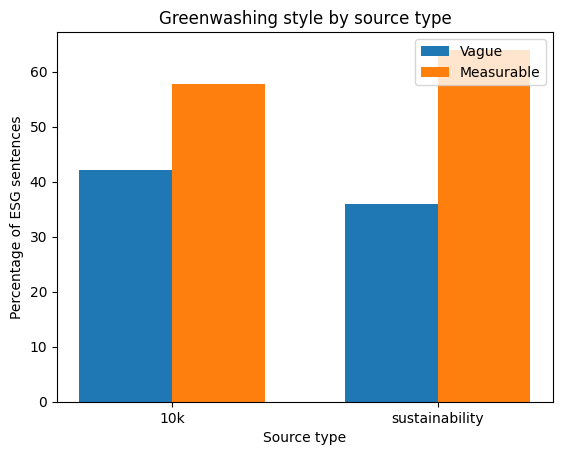

In [52]:
import matplotlib.pyplot as plt

green_stats = pd.read_csv(RESULTS_DIR / "greenwashing_statistics.csv")

plt.figure()
x = green_stats["source_type"]
vague = green_stats["percent_vague"]
meas = green_stats["percent_measurable"]
width = 0.35
idx = range(len(x))
plt.bar([i - width/2 for i in idx], vague, width)
plt.bar([i + width/2 for i in idx], meas, width)
plt.xticks(idx, x)
plt.ylabel("Percentage of ESG sentences")
plt.xlabel("Source type")
plt.legend(["Vague", "Measurable"])
plt.title("Greenwashing style by source type")
plt.show()


In [67]:
!pip install pymupdf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 12.9 MB/s eta 0:00:00


In [68]:
from google.colab import files
from pathlib import Path
import pandas as pd
import gc
import re
import fitz

uploaded = files.upload()
fname = list(uploaded.keys())[0]
path = Path(fname)

doc_text = ""
with fitz.open(str(path)) as pdf:
    for page in pdf:
        doc_text += page.get_text()

MAX_CHARS = 1_000_000
if len(doc_text) > MAX_CHARS:
    doc_text = doc_text[:MAX_CHARS]

nlp.max_length = MAX_CHARS + 1
doc = nlp(doc_text)
sentences = [s.text.strip() for s in doc.sents if len(s.text.strip()) > 5]

user_doc_id = path.stem
df = pd.DataFrame({
    "doc_id": [user_doc_id] * len(sentences),
    "source_type": ["upload"] * len(sentences),
    "sentence": sentences,
})

df["pillar_baseline"] = df["sentence"].apply(baseline_esg_pillar)
df["pillar_model"] = df["pillar_baseline"]

MAX_FINBERT_SENT = 500
df["sentiment_label"] = "neutral"

if len(df) > 0:
    sample = df.sample(n=min(MAX_FINBERT_SENT, len(df)), random_state=42)
    sent_list = sample["sentence"].tolist()
    out = sentiment_predict_batch(sent_list, batch_size=16, max_length=64)
    if isinstance(out, tuple):
        sent_labels = out[0]
    else:
        sent_labels = out
    clean = []
    for v in sent_labels:
        if isinstance(v, str):
            clean.append(v.strip().lower())
        elif isinstance(v, (list, tuple)) and len(v) > 0:
            clean.append(str(v[0]).strip().lower())
        else:
            clean.append("neutral")
    mapping = {"negative": "negative", "neutral": "neutral", "positive": "positive"}
    mapped = [mapping.get(x, "neutral") for x in clean[: len(sample)]]
    sample["sentiment_label"] = mapped
    df.loc[sample.index, "sentiment_label"] = sample["sentiment_label"]

def label_to_numeric(label):
    t = str(label).lower()
    if t.startswith("positive"):
        return 1.0
    if t.startswith("negative"):
        return -1.0
    return 0.0

df["sentiment_numeric"] = df["sentiment_label"].apply(label_to_numeric)
df["greenwash_label"] = df["sentence"].apply(is_measurable)
df["greenwash_label_str"] = df["greenwash_label"].map({0: "vague", 1: "measurable"})

scores = compute_corpus_pillar_scores(df)

MAX_SUMMARY_SENT = 300
summary_rows = []
for pillar in ["E", "S", "G"]:
    sub = df[df["pillar_model"] == pillar]
    if len(sub) == 0:
        continue
    sents = sub["sentence"]
    if len(sents) > MAX_SUMMARY_SENT:
        sents = sents.sample(n=MAX_SUMMARY_SENT, random_state=42)
    sents = sents.tolist()
    summary_text = extractive_summary(sents, max_sentences=5)
    summary_rows.append({
        "source_type": "upload",
        "pillar": pillar,
        "summary": summary_text
    })

summaries = pd.DataFrame(summary_rows)

illegal = re.compile(r'[\x00-\x08\x0b-\x0c\x0e-\x1f]')
def clean_df(d):
    for c in d.columns:
        if d[c].dtype == object:
            d[c] = d[c].astype(str).apply(lambda x: illegal.sub("", x))
    return d

df = clean_df(df)
scores = clean_df(scores)
summaries = clean_df(summaries)

with pd.ExcelWriter(RESULTS_DIR / f"{user_doc_id}_upload_analysis.xlsx") as writer:
    df.to_excel(writer, sheet_name="sentence_output", index=False)
    scores.to_excel(writer, sheet_name="pillar_scores", index=False)
    summaries.to_excel(writer, sheet_name="pillar_summaries", index=False)

print("\n=== PILLAR SCORES ===\n")
print(scores)

print("\n=== PILLAR SUMMARIES ===\n")
print(summaries)

print("\n=== SAMPLE SENTENCES ===\n")
print(df[["sentence", "pillar_model", "sentiment_label", "greenwash_label_str"]].head(20))

del df, scores, summaries
gc.collect()


Saving sustainability-report-2024.pdf to sustainability-report-2024 (3).pdf

=== PILLAR SCORES ===

  source_type pillar  avg_sentiment  esg_score_0_100
0      upload      E       0.036232        51.811594
1      upload      S       0.046729        52.336449
2      upload      G       0.012739        50.636943

=== PILLAR SUMMARIES ===

  source_type pillar                                            summary
0      upload      E  The reported alignment deltas are reflective o...
1      upload      S  To help us realize this ambition, our sustaina...
2      upload      G  Regulatory \ncompliance \n–\nclient protection...

=== SAMPLE SENTENCES ===

                                             sentence pillar_model  \
0   Sustainability Report\n2024\nThinking and acti...            E   
1   We have done so both based on \nour commitment...         None   
2   Our sustainability and impact strategy is base...            S   
3   We support our clients in the transition to a ...            E

25279

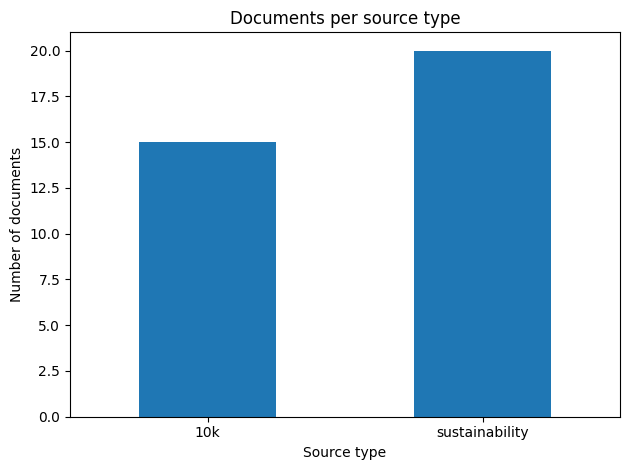

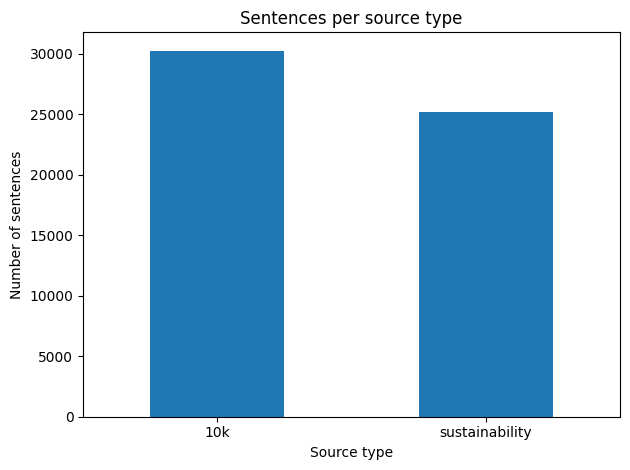

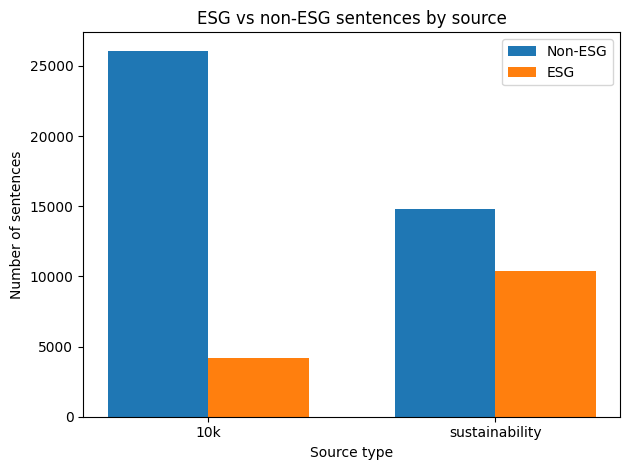

<Figure size 640x480 with 0 Axes>

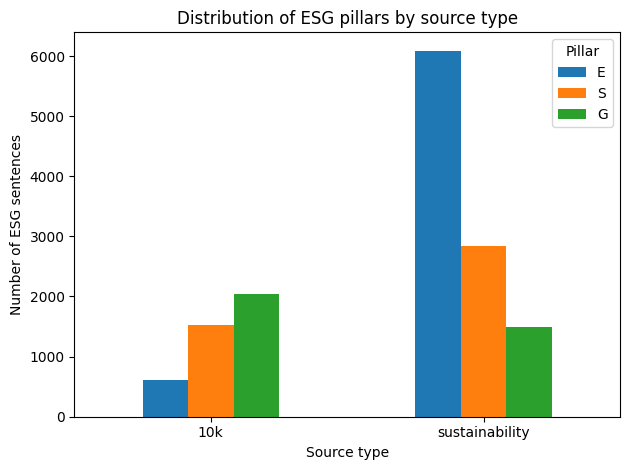

<Figure size 640x480 with 0 Axes>

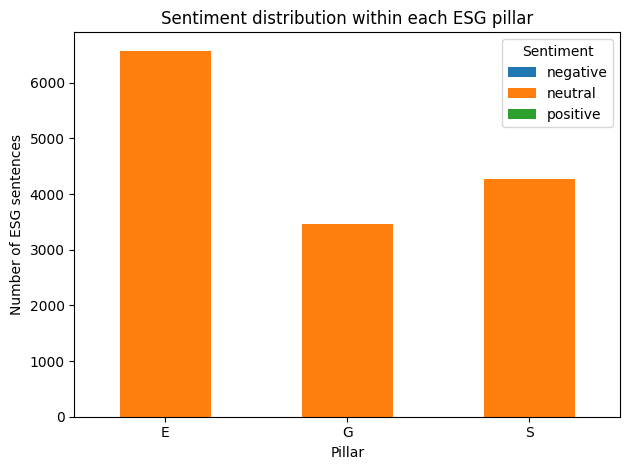

<Figure size 640x480 with 0 Axes>

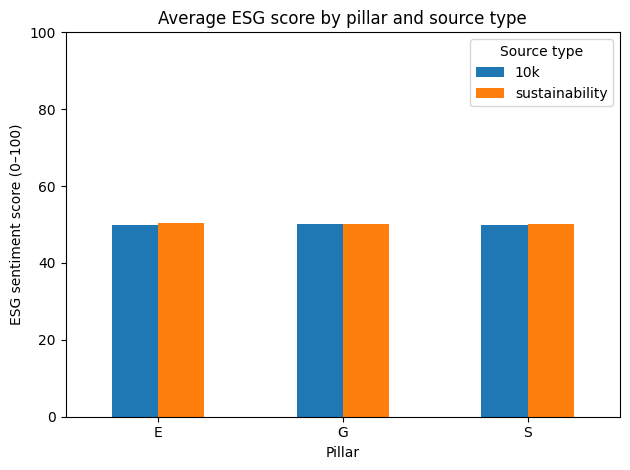

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(RESULTS_DIR / "final_pipeline_output.csv")
corpus_scores = pd.read_csv(RESULTS_DIR / "corpus_pillar_scores.csv")

doc_counts = df.groupby("source_type")["doc_id"].nunique()
plt.figure()
doc_counts.plot(kind="bar")
plt.ylabel("Number of documents")
plt.xlabel("Source type")
plt.title("Documents per source type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

sent_counts = df["source_type"].value_counts()
plt.figure()
sent_counts.plot(kind="bar")
plt.ylabel("Number of sentences")
plt.xlabel("Source type")
plt.title("Sentences per source type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

mask_esg = df["pillar_model"].isin(["E", "S", "G"])
esg_counts = df[mask_esg]["source_type"].value_counts()
non_esg_counts = df[~mask_esg]["source_type"].value_counts()
all_sources = sorted(set(df["source_type"].dropna().tolist()))
esg_vals = [esg_counts.get(s, 0) for s in all_sources]
non_esg_vals = [non_esg_counts.get(s, 0) for s in all_sources]
idx = range(len(all_sources))
width = 0.35
plt.figure()
plt.bar([i - width/2 for i in idx], non_esg_vals, width, label="Non-ESG")
plt.bar([i + width/2 for i in idx], esg_vals, width, label="ESG")
plt.xticks(idx, all_sources)
plt.ylabel("Number of sentences")
plt.xlabel("Source type")
plt.title("ESG vs non-ESG sentences by source")
plt.legend()
plt.tight_layout()
plt.show()

esg_df = df[mask_esg].copy()
pillar_counts = (
    esg_df.groupby(["source_type", "pillar_model"])
    .size()
    .unstack(fill_value=0)
)
for col in ["E", "S", "G"]:
    if col not in pillar_counts.columns:
        pillar_counts[col] = 0
pillar_counts = pillar_counts[["E", "S", "G"]]
plt.figure()
pillar_counts.plot(kind="bar")
plt.ylabel("Number of ESG sentences")
plt.xlabel("Source type")
plt.title("Distribution of ESG pillars by source type")
plt.xticks(rotation=0)
plt.legend(title="Pillar")
plt.tight_layout()
plt.show()

sent_pillar = (
    esg_df.groupby(["pillar_model", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)
for col in ["negative", "neutral", "positive"]:
    if col not in sent_pillar.columns:
        sent_pillar[col] = 0
sent_pillar = sent_pillar[["negative", "neutral", "positive"]]
plt.figure()
sent_pillar.plot(kind="bar", stacked=True)
plt.ylabel("Number of ESG sentences")
plt.xlabel("Pillar")
plt.title("Sentiment distribution within each ESG pillar")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

pivot_scores = corpus_scores.pivot(index="pillar",
                                   columns="source_type",
                                   values="esg_score_0_100")
plt.figure()
pivot_scores.plot(kind="bar")
plt.ylim(0, 100)
plt.ylabel("ESG sentiment score (0–100)")
plt.xlabel("Pillar")
plt.title("Average ESG score by pillar and source type")
plt.xticks(rotation=0)
plt.legend(title="Source type")
plt.tight_layout()
plt.show()
